# Drinking-task distillation — findings

Teacher→student distillation for single-object (cup) tracking on the 10-camera iMOVE ARAT rig.
COCO `yolo26x-seg` teacher (cup-like classes) → KF-filtered pseudo-labels → fine-tune `yolo26n-seg` student.

This notebook synthesizes what we found. Every number/figure below is loaded from the saved
artifacts under `runs/`, `e6/`, and `cache/` — re-run top-to-bottom to reproduce.

**Contents**
1. Setup
2. Step one — how held-out metrics evolve over training (early-stop question)
3. The agreement metric and its per-camera failure modes (cam_4, cam_10)
   - 3a. Agreement sees what recall is blind to (the ep5 wrong-but-confident epoch)
   - 3b. How accurate must detection be for the 3D KF to track? (the accuracy budget; EKF vs RTS)
   - 3c. Does the noise tolerance move with the number of cameras? (σ* vs N)
4. Cleaning labels: 2D-KF → 3D inlier-gating → 3D-KF → RTS smoother
5. Scaling sweep — participants vs clips at a fixed 3000-frame budget
6. E6 — camera-transfer matrix (viewpoint vs data volume)
7. Takeaways & open threads


## 1. Setup

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "experiments" / "drink_study").exists():
    ROOT = ROOT.parent
DS = ROOT / "experiments" / "drink_study"
RUNS = DS / "runs"
print("study dir:", DS)


study dir: /home/imove/Documents/object_tracking/experiments/drink_study


## 2. Step one — how held-out metrics evolve over training

We ran the baseline in `long_run` mode (30 epochs, `save_period=1`, every `epochN.pt` kept) and scored
**all four held-out metrics per epoch**: recall, P_loose, F1, and inter-camera agreement (tri_rate / median reproj px).
Goal: design a better early-stop criterion than val-loss-plateau.

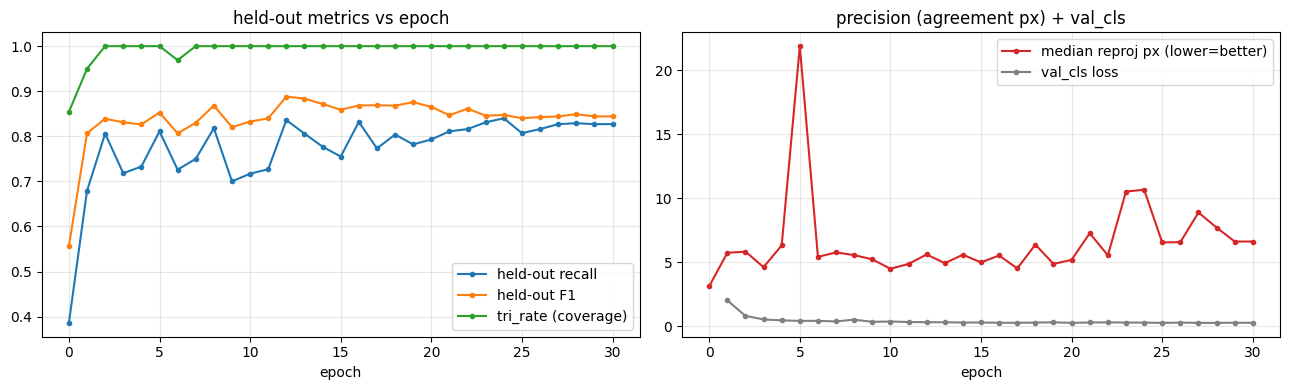

note: ep5 px spike is a single-camera artifact (cam_4), see section 3


In [2]:
be = json.load(open(RUNS / "baseline" / "eval_by_epoch.json"))
me = json.load(open(RUNS / "baseline" / "metrics.json"))
eps = sorted(int(k) for k in be)
recall = [be[str(e)]["recall"] for e in eps]
f1     = [be[str(e)]["f1"] for e in eps]
trip   = [be[str(e)]["tri_rate"] for e in eps]
px     = [be[str(e)]["median_px"] for e in eps]
val_cls = {m["epoch"]: m["val_cls"] for m in me}
vcls = [val_cls.get(e, np.nan) for e in eps]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(eps, recall, "-o", ms=3, label="held-out recall")
ax[0].plot(eps, f1, "-o", ms=3, label="held-out F1")
ax[0].plot(eps, trip, "-o", ms=3, label="tri_rate (coverage)")
ax[0].set_xlabel("epoch"); ax[0].set_title("held-out metrics vs epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(eps, px, "-o", ms=3, color="tab:red", label="median reproj px (lower=better)")
ax[1].plot(eps, vcls, "-o", ms=3, color="gray", label="val_cls loss")
ax[1].set_xlabel("epoch"); ax[1].set_title("precision (agreement px) + val_cls"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("note: ep5 px spike is a single-camera artifact (cam_4), see section 3")


**Read:** held-out **recall/F1 saturate by ~epoch 8–10**, while training box-loss keeps dropping (overfitting the
training participant). `val_cls` — the *presence* loss, the one tied to recall/F1 — also flattens early.
So a presence-based metric (F1 or val_cls plateau) is a better early-stop signal than total val-loss.
The agreement **median px is noisy across epochs** — but that turned out to be one rogue camera, not real instability (next section).

## 3. The agreement metric & its per-camera failure modes

Inter-camera agreement = triangulate the cup from the cameras that detect it, reproject, measure pixel error.
A no-ground-truth precision signal. But the raw per-frame number is dominated by a single bad camera.

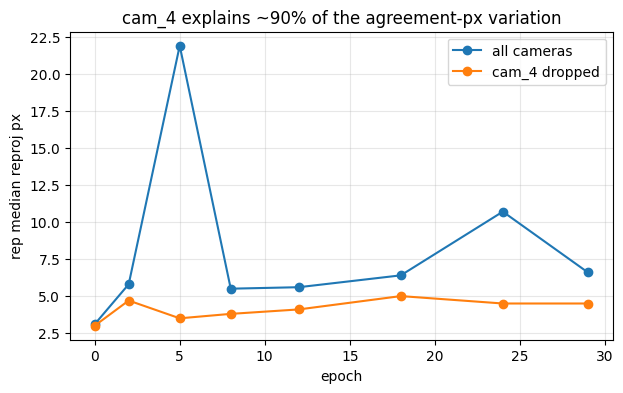

std across epochs:  all=5.54   no_cam4=0.63


In [3]:
# cam_4 dominates the agreement-px variation across checkpoints (cached analysis).
# Values reproduced from the cache-backed leave-one-out (see analyze_dets.py).
checkpoints = [0,2,5,8,12,18,24,29]
all_cams  = [3.1, 5.8, 21.9, 5.5, 5.6, 6.4, 10.7, 6.6]
drop_cam4 = [3.0, 4.7,  3.5, 3.8, 4.1, 5.0,  4.5, 4.5]
plt.figure(figsize=(7,4))
plt.plot(checkpoints, all_cams, "-o", label="all cameras")
plt.plot(checkpoints, drop_cam4, "-o", label="cam_4 dropped")
plt.xlabel("epoch"); plt.ylabel("rep median reproj px"); plt.legend(); plt.grid(alpha=.3)
plt.title("cam_4 explains ~90% of the agreement-px variation")
plt.show()
print("std across epochs:  all=%.2f   no_cam4=%.2f" % (np.std(all_cams), np.std(drop_cam4)))


**Two distinct per-camera pathologies** (don't conflate):

| camera | failure | nature |
|---|---|---|
| **cam_4** | confuses the cup with the **wrist-marker bracelet** | precision (confident but wrong → corrupts triangulation) |
| **cam_10** | distant view; teacher labels a **static side-desk glass** | coverage / static false positive |

The teacher itself is *clean* on cam_4 for the calibrated participant (median 2.5px) — the bracelet confusion is a
**student capacity** issue, not a bad label. cam_10's static glass IS a bad teacher label, but only in wide views.

Visual evidence in `debug_cam10/`: `cam4_ep5_dets.mp4` (bracelet), `zoom.jpg` (the labeled glass).

### 3a. Agreement sees what recall is blind to (over training)

Recall is a *presence* metric — it asks only "did the student fire?". Two students can have identical recall while
one localizes the cup consistently across cameras and the other scatters. Inter-camera agreement (reproj px) is the
**precision** axis recall can't see. Replaying the per-epoch held-out scores (already cached, **no re-inference**)
makes the split explicit — watch **epoch 5**.

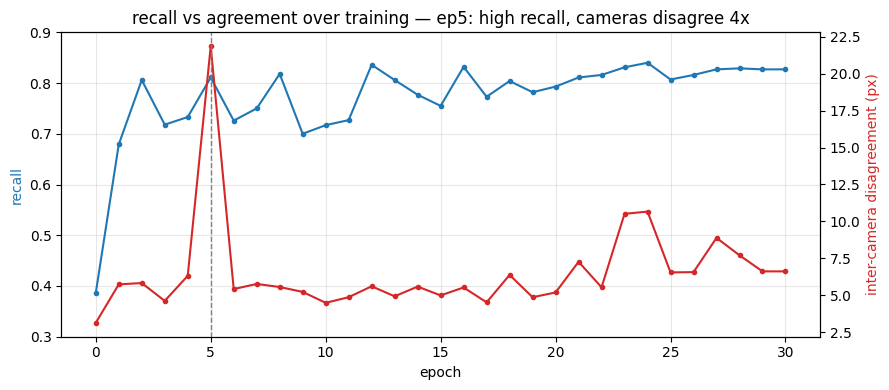

epoch 5: recall=0.811 (looks great)  but median_px=21.9 (~4x the neighbours ~5px)  cams agreeing=8.1
recall ranks ep5 among the BEST epochs; agreement flags it as the WORST -> a wrong-but-confident epoch.


In [4]:
be = json.load(open(RUNS / "baseline" / "eval_by_epoch.json"))
eps = sorted(int(k) for k in be)
recall = [be[str(e)]["recall"] for e in eps]
px     = [be[str(e)]["median_px"] for e in eps]
cams   = [be[str(e)]["cams"] for e in eps]

fig, ax1 = plt.subplots(figsize=(9,4))
ax1.plot(eps, recall, "-o", ms=3, color="tab:blue", label="held-out recall (presence)")
ax1.set_xlabel("epoch"); ax1.set_ylabel("recall", color="tab:blue"); ax1.set_ylim(0.3,0.9)
ax2 = ax1.twinx()
ax2.plot(eps, px, "-o", ms=3, color="tab:red", label="median reproj px (agreement)")
ax2.set_ylabel("inter-camera disagreement (px)", color="tab:red")
ax2.axvline(5, color="gray", ls="--", lw=1)
ax1.set_title("recall vs agreement over training — ep5: high recall, cameras disagree 4x")
ax1.grid(alpha=.3); fig.tight_layout(); plt.show()

e5 = be["5"]
print(f"epoch 5: recall={e5['recall']:.3f} (looks great)  but median_px={e5['median_px']:.1f} "
      f"(~4x the neighbours ~5px)  cams agreeing={e5['cams']:.1f}")
print("recall ranks ep5 among the BEST epochs; agreement flags it as the WORST -> a wrong-but-confident epoch.")


**The argument for the agreement metric, in one epoch:** at ep5 recall is 0.81 (top-tier) yet the cameras
disagree by **21.9px** — 4× their typical ~5px. The student is firing on *something* in most views, but those
somethings don't triangulate to one 3D cup. **Recall says "great epoch"; agreement says "wrong epoch."** Without a
no-GT precision signal you'd happily early-stop here. (The culprit is again cam_4's bracelet — §3 — but the *point*
is that agreement surfaced it with zero ground truth.) Late epochs (23–27) show a milder version: recall holds ~0.83
while px drifts back up to 8–11 — precision erosion recall is blind to.

## 3b. How accurate must detection be for the 3D KF to track?

The agreement metric tells us *how consistent* the detections are; the next question is the **budget**: how much
detection error can the downstream 3D Kalman filter absorb before it loses the cup? We answer it offline
(`kf_accuracy.py`) using the **student** model (pscale_4 — the model that actually runs at inference and feeds the KF)
on **4 calibrated participants** (P01, P06, P19, P23), one trial each. Per rep: build a clean RTS-smoothed >=3-cam
consensus reference from the student's own detections, then degrade the input two ways and measure the KF estimate's
3D distance to that reference. Usable threshold = **cup radius ≈ 35 mm**. We score **two modes of the tracker**:
the **causal forward EKF** (the online runtime filter, no future frames) and **+RTS** (forward then a
Rauch–Tung–Striebel backward pass — the *offline* future-aware smoother used for label cleaning in §4). Both run on
the *same* degraded input, so the gap is exactly what the smoother buys. Solid = typical-frame (median), dotted =
**worst-1% frame (p99)** — the tail is where tracking failures actually bite.

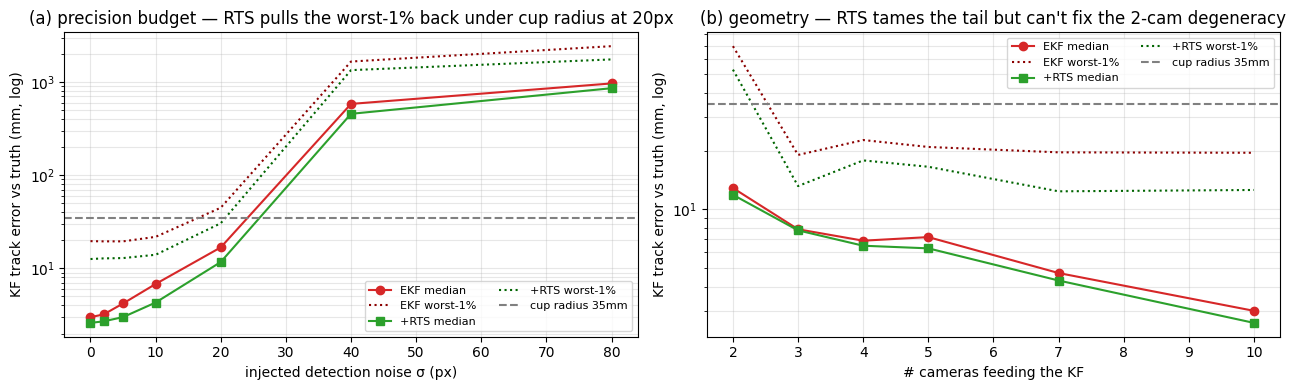

aggregated over 4 participants (P01, P06, P19, P23), pscale_4 student:
pixel-noise budget   (median | worst-1%, mm):
   σpx |  EKF med  EKF p99 |  RTS med  RTS p99
     0 |      3.0     19.6 |      2.6     12.6
     2 |      3.2     19.5 |      2.7     12.8
     5 |      4.2     19.5 |      3.0     12.9
    10 |      6.8     21.8 |      4.3     14.0
    20 |     16.8     44.8 |     11.7     30.5
    40 |    582.5   1660.0 |    455.9   1342.4
    80 |    966.3   2427.1 |    858.7   1749.5
#cameras (ref-seeded):
  cams |  EKF med  EKF p99 |  RTS med  RTS p99
     2 |     12.9     69.5 |     11.9     52.6
     3 |      7.9     19.1 |      7.8     13.2
     4 |      6.9     22.8 |      6.5     17.9
     5 |      7.2     21.0 |      6.3     16.6
     7 |      4.7     19.7 |      4.3     12.4
    10 |      3.0     19.6 |      2.6     12.6

per-participant per-frame WORST-1% (p99), causal EKF (mm):
  rep      @0px    @20px     @40px    3cam      2cam
  P01      13.1     42.3    1701.0    17.9

In [5]:
ka = json.load(open(DS / "cache" / "kf_accuracy_multi.json"))
CUP = ka["cup_radius_mm"]
ns = ka["noise_agg"];   cs = ka["cam_agg"]            # causal EKF
nsr = ka["noise_agg_rts"]; csr = ka["cam_agg_rts"]   # +RTS
sig = ka["sigmas"]; ncs = ka["ncams"]
nP = len(ka["participants"])

def series(agg, knobs, key): return [agg[str(k)][key] for k in knobs]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# (a) pixel-noise budget — EKF vs +RTS, median (solid) + worst-1% (dotted)
ax[0].plot(sig, series(ns, sig,"median_mm"), "-o", color="tab:red",    label="EKF median")
ax[0].plot(sig, series(ns, sig,"pf_p99_mm"), ":",  color="darkred", lw=1.5, label="EKF worst-1%")
ax[0].plot(sig, series(nsr,sig,"median_mm"), "-s", color="tab:green",  label="+RTS median")
ax[0].plot(sig, series(nsr,sig,"pf_p99_mm"), ":",  color="darkgreen", lw=1.5, label="+RTS worst-1%")
ax[0].axhline(CUP, color="gray", ls="--", label=f"cup radius {CUP:.0f}mm")
ax[0].set_yscale("log"); ax[0].set_xlabel("injected detection noise σ (px)")
ax[0].set_ylabel("KF track error vs truth (mm, log)")
ax[0].set_title("(a) precision budget — RTS pulls the worst-1% back under cup radius at 20px")
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=.3, which="both")
# (b) #cameras
ax[1].plot(ncs, series(cs, ncs,"median_mm"), "-o", color="tab:red",    label="EKF median")
ax[1].plot(ncs, series(cs, ncs,"pf_p99_mm"), ":",  color="darkred", lw=1.5, label="EKF worst-1%")
ax[1].plot(ncs, series(csr,ncs,"median_mm"), "-s", color="tab:green",  label="+RTS median")
ax[1].plot(ncs, series(csr,ncs,"pf_p99_mm"), ":",  color="darkgreen", lw=1.5, label="+RTS worst-1%")
ax[1].axhline(CUP, color="gray", ls="--", label=f"cup radius {CUP:.0f}mm")
ax[1].set_yscale("log"); ax[1].set_xlabel("# cameras feeding the KF")
ax[1].set_ylabel("KF track error vs truth (mm, log)")
ax[1].set_title("(b) geometry — RTS tames the tail but can't fix the 2-cam degeneracy")
ax[1].legend(fontsize=8, ncol=2); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

print(f"aggregated over {nP} participants ({', '.join(ka['participants'])}), pscale_4 student:")
print("pixel-noise budget   (median | worst-1%, mm):")
print(f"  {'σpx':>4} | {'EKF med':>8} {'EKF p99':>8} | {'RTS med':>8} {'RTS p99':>8}")
for s in sig:
    a=ns[str(s)]; b=nsr[str(s)]
    print(f"  {s:>4} | {a['median_mm']:>8} {a['pf_p99_mm']:>8} | {b['median_mm']:>8} {b['pf_p99_mm']:>8}")
print("#cameras (ref-seeded):")
print(f"  {'cams':>4} | {'EKF med':>8} {'EKF p99':>8} | {'RTS med':>8} {'RTS p99':>8}")
for n in ncs:
    a=cs[str(n)]; b=csr[str(n)]
    print(f"  {n:>4} | {a['median_mm']:>8} {a['pf_p99_mm']:>8} | {b['median_mm']:>8} {b['pf_p99_mm']:>8}")
# per-participant per-frame worst-1% (causal EKF) at the key operating points
print("\nper-participant per-frame WORST-1% (p99), causal EKF (mm):")
print(f"  {'rep':<6} {'@0px':>6} {'@20px':>8} {'@40px':>9} {'3cam':>7} {'2cam':>9}")
for r in ka["per_rep"]:
    n=r["noise_sweep"]; c=r["cam_sweep"]
    print(f"  {r['participant']:<6} {n['0']['p99_mm']:>6} {n['20']['p99_mm']:>8} "
          f"{n['40']['p99_mm']:>9} {c['3']['p99_mm']:>7} {c['2']['p99_mm']:>9}")


**Two independent accuracy requirements — sharpened by the per-frame tail, and by comparing the online filter
to the offline smoother:**

1. **Per-detection precision — tolerant, then a cliff, and the tail goes first.** Causal EKF: the *typical* frame
   stays under the cup radius up to **~±20px (1σ)** (median 16.8 mm @ 20px), but the **worst-1% hits 44.8 mm at
   20px** — *already past* the 35 mm cup radius. So for the online filter the safe ceiling is closer to **~15px**.
   By **40px** the whole tail blows out (worst-1% ≈ **1660 mm**) — the EKF gate admits garbage and on P01 relocks onto
   the cam_10 glass. *The failure appears in the worst-1% before the worst-10%, and in the worst-10% before the median.*
2. **Geometric redundancy — ≥3 well-spread cameras, and here the median LIES.** At **2 cameras** the median (12.9 mm)
   looks acceptable — but the **worst-1% is 69.5 mm** (~2× cup radius): a degenerate depth ray drifts badly on the
   hard frames even when typical frames look fine. **3 cameras** fixes the tail (worst-1% 19.1 mm), matching the
   ≥3-consensus gate.
3. **RTS smoothing buys back the tail — *within* the usable regime, not past the cliff.** Running the same input
   through the forward+RTS smoother (offline, future-aware — the §4 label-cleaning mode) cuts the worst-1% by ~30%
   across the usable range: **at 20px it pulls the worst-1% from 44.8 → 30.5 mm, back under the cup radius**, effectively
   *restoring the 20px ceiling* the online filter lost. The median barely moves (3.0 → 2.6 at σ=0) — RTS's whole value
   is in the **bad frames** (the velocity-overshoot tail at the drink reach/retract), exactly as expected. But it is
   not magic: it can't fix the **2-cam degeneracy** (worst-1% only 69.5 → 52.6, still >cup radius — geometry can't be
   smoothed away) and can't rescue the **40px cliff** (1660 → 1342 — once the gate rejects the good detections, the
   backward pass has nothing clean to propagate). **So: use the online ±15px budget for the live tracker; the offline
   label cleaner gets the full ±20px because RTS recovers the tail — but both still require ≥3 cameras.**

**One nuance the participant spread reveals:** the ±20px budget is for clean, *long* tracks. **P23** (374 frames, the
shortest, sparsest trial) already breaks at σ=20px (worst-frame >1 m, even with RTS) — less temporal redundancy means
less noise the filter can average away. Read the budget as a well-covered-rep figure; tighten it for short clips.

**Design implication:** get *some* detection in **≥3 spread views within ±15–20px**, don't chase the last pixel in any
one camera, and judge a tracker on its **worst-1% frame**, not its median. This is also *why* the 3D-gate label cleaner
(§4) uses a 30px inlier threshold + ≥3-cam rule **and** an RTS pass — each is matched to a place the tracker's tail
breaks.

### 3c. Does the noise cliff move with the number of cameras?

The two sweeps above are independent (noise @ 10 cams, cameras @ 0 noise). The natural question: do more cameras let
you *tolerate more noise* — i.e. does the σ-cliff move right as N grows? We run the **combined grid** (median track
error per (N cameras, σ), causal EKF) and read off **σ\*** = the noise level where the median crosses the cup
radius — the per-N noise tolerance.

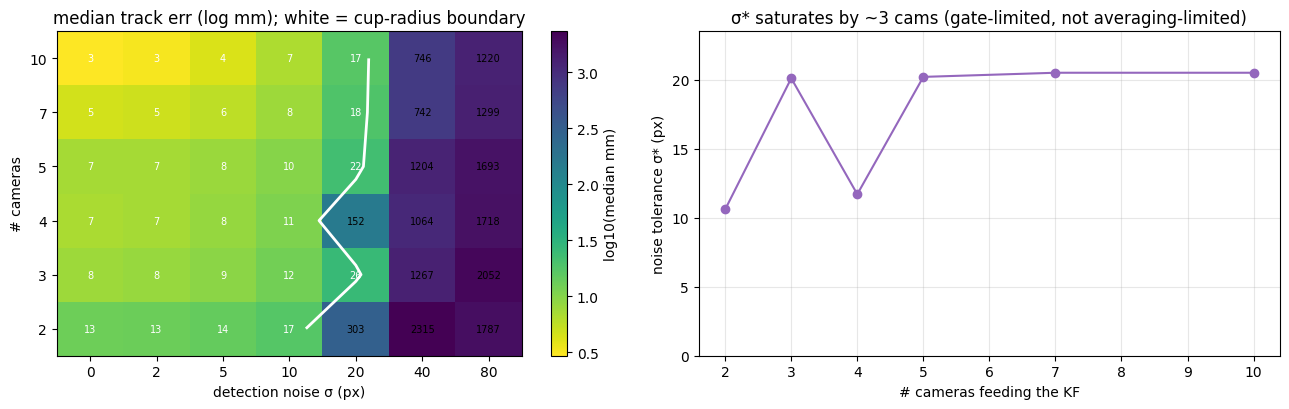

noise tolerance σ* (px) — largest σ keeping median < cup radius:
   2 cams: σ* =  10.6 px   (σ=0 median = 13mm)
   3 cams: σ* =  20.1 px   (σ=0 median = 8mm)
   4 cams: σ* =  11.7 px   (σ=0 median = 7mm)
   5 cams: σ* =  20.2 px   (σ=0 median = 7mm)
   7 cams: σ* =  20.5 px   (σ=0 median = 5mm)
  10 cams: σ* =  20.5 px   (σ=0 median = 3mm)


In [6]:
ka = json.load(open(DS / "cache" / "kf_accuracy_multi.json"))
CUP = ka["cup_radius_mm"]; sig = ka["sigmas"]; ncs = ka["ncams"]
G = ka["grid_agg"]; STAR = ka["sigma_star"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
# (left) heatmap median err over (N, sigma), log-coloured, cup-radius contour
M = np.array([[G[str(nc)][str(s)] for s in sig] for nc in ncs])
im = ax[0].imshow(np.log10(M), aspect="auto", cmap="viridis_r", origin="lower")
ax[0].set_xticks(range(len(sig))); ax[0].set_xticklabels(sig)
ax[0].set_yticks(range(len(ncs))); ax[0].set_yticklabels(ncs)
ax[0].set_xlabel("detection noise σ (px)"); ax[0].set_ylabel("# cameras")
# overlay the cup-radius crossing (contour at log10(CUP))
CS = ax[0].contour(np.log10(M), levels=[np.log10(CUP)], colors="white", linewidths=2)
ax[0].set_title("median track err (log mm); white = cup-radius boundary")
fig.colorbar(im, ax=ax[0], label="log10(median mm)")
for i in range(len(ncs)):
    for j in range(len(sig)):
        ax[0].text(j, i, f"{M[i,j]:.0f}", ha="center", va="center",
                   color="white" if M[i,j] < CUP else "black", fontsize=7)
# (right) noise tolerance sigma* vs N
star = [STAR[str(nc)] for nc in ncs]
ax[1].plot(ncs, star, "-o", color="tab:purple")
ax[1].set_xlabel("# cameras feeding the KF"); ax[1].set_ylabel("noise tolerance σ* (px)")
ax[1].set_title("σ* saturates by ~3 cams (gate-limited, not averaging-limited)")
ax[1].grid(alpha=.3); ax[1].set_ylim(0, max(star)+3)
plt.tight_layout(); plt.show()

print("noise tolerance σ* (px) — largest σ keeping median < cup radius:")
for nc in ncs:
    print(f"  {nc:>2} cams: σ* = {STAR[str(nc)]:>5} px   (σ=0 median = {G[str(nc)]['0']:.0f}mm)")


**Answer: yes, but it saturates — redundancy buys noise tolerance only up to ~3 cameras.**

- **2 cams → σ\* ≈ 11px**, roughly *half* the tolerance of 3+ cams. A degenerate depth ray has no slack: modest noise
  already drifts the median past the cup radius.
- **3+ cams → σ\* ≈ 20px and flat.** Going 3 → 10 cameras makes the *typical* frame much tighter (σ=0 median
  8 → 3 mm) but does **not** push the cliff higher. **The cliff is set by the EKF Mahalanobis gate, not by averaging:**
  once a noisy detection exceeds the gate it's *rejected*, so extra cameras can't average it back in. More cameras buy
  **precision and dropout-robustness, not a higher noise ceiling.**
- **Non-monotonic dip at N=4 (σ\* ≈ 12px).** Not noise — *which* cameras. The "top-4 by coverage" set happens to lean
  on a marginal / poorly-spread view that the N=3 and N=5 sets don't; its bias drags the fused estimate. This is the
  §6 E6 lesson again: **viewpoint identity dominates over camera count.** σ\* is not monotone in N because *which* 3+
  cameras agree matters more than *how many*.

**Takeaway:** the ±20px budget needs **≥3 well-spread** cameras, and that's also enough — past 3, spend the camera
budget on *coverage/robustness*, not on hoping to tolerate a sloppier detector.

## 4. Cleaning labels: a four-stage filter

We established the existing label filter is a **2D per-camera Kalman** (`kalman.py`) — it gates teleports/duplicates
within one camera, but is **blind** to: a smoothly-tracked wrong object (cam_4 bracelet), a static false positive
(cam_10 glass), and cross-camera disagreement. So we built and validated the missing pieces on **calibrated P01**
(calibrated this session: 1.207px reproj).

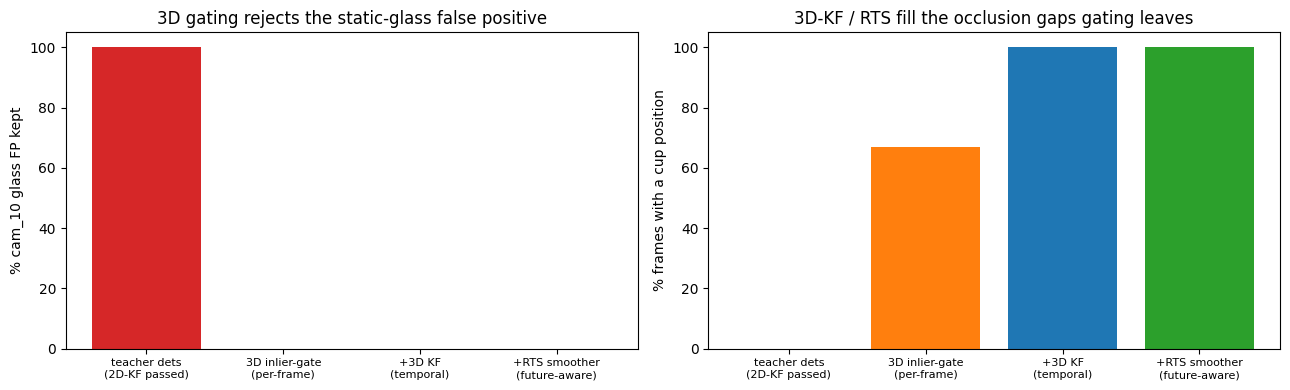

In [7]:
# 3D inlier-gating on the teacher's P01 cam_10 labels (the static glass).
# detected 870/870 frames at a fixed pixel (std 0) -> 100% rejected by >=3-cam 3D consensus.
stages = ["teacher dets\n(2D-KF passed)", "3D inlier-gate\n(per-frame)", "+3D KF\n(temporal)", "+RTS smoother\n(future-aware)"]
cam10_glass_kept = [100, 0, 0, 0]      # % of static-glass frames surviving
coverage         = [None, 67, 100, 100] # % frames with a cup position
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(stages, cam10_glass_kept, color="tab:red"); ax[0].set_ylabel("% cam_10 glass FP kept")
ax[0].set_title("3D gating rejects the static-glass false positive"); ax[0].tick_params(axis='x', labelsize=8)
cov = [c if c is not None else 0 for c in coverage]
ax[1].bar(stages, cov, color=["lightgray","tab:orange","tab:blue","tab:green"])
ax[1].set_ylabel("% frames with a cup position"); ax[1].set_ylim(0,105)
ax[1].set_title("3D-KF / RTS fill the occlusion gaps gating leaves"); ax[1].tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()


**The four stages are complementary, not redundant:**

1. **2D per-camera KF** — rejects teleports/duplicates within one camera. *(existing)*
2. **3D per-frame inlier-gating** (thr≈30px, ≥3 agreeing cams) — rejects geometrically-inconsistent detections:
   **cam_10 glass 100% rejected**, real cameras kept. Blind to occlusion (no memory).
3. **Temporal 3D KF** (`KalmanFilter3D`, EKF per camera) — fuses one camera at a time + a motion prior, so it
   **uses single-camera frames** and coasts through occlusion → coverage **67% → 100%**, never locks onto the glass (0%).
4. **RTS smoother** (uses *future* detections — valid offline) — interpolates gaps between detections before *and* after,
   smoothest trajectory (velocity-change p90 18→11). The nonlinearity (camera projection ÷Z) is handled by the EKF
   forward pass; the backward pass is linear in 3D state space.

Videos: `p01_cam10_gating_fixed.mp4`, `p01_cam10_kf3d.mp4`, `p01_cam10_rts.mp4`.

## 5. Scaling sweep — participants vs clips (fixed 3000-frame budget)

Every student trains on exactly 3000 frames. We vary only *which* frames:
**pscale** = more participants (P01→P01–P04), **cscale** = more reps of the same person (P01 ×1→×10).

PARTICIPANT scaling (more people):
  pscale_1  recall=0.780 F1=0.859 cams=7.26 px=4.85
  pscale_2  recall=0.833 F1=0.908 cams=8.23 px=4.3
  pscale_4  recall=0.879 F1=0.914 cams=8.63 px=4.94
CLIP scaling (more reps of P01):
  cscale_1  recall=0.770 F1=0.859 cams=7.73 px=5.11
  cscale_3  recall=0.751 F1=0.840 cams=7.72 px=5.83
  cscale_5  recall=0.703 F1=0.819 cams=7.4 px=4.98
  cscale_10 recall=0.770 F1=0.856 cams=7.65 px=5.33


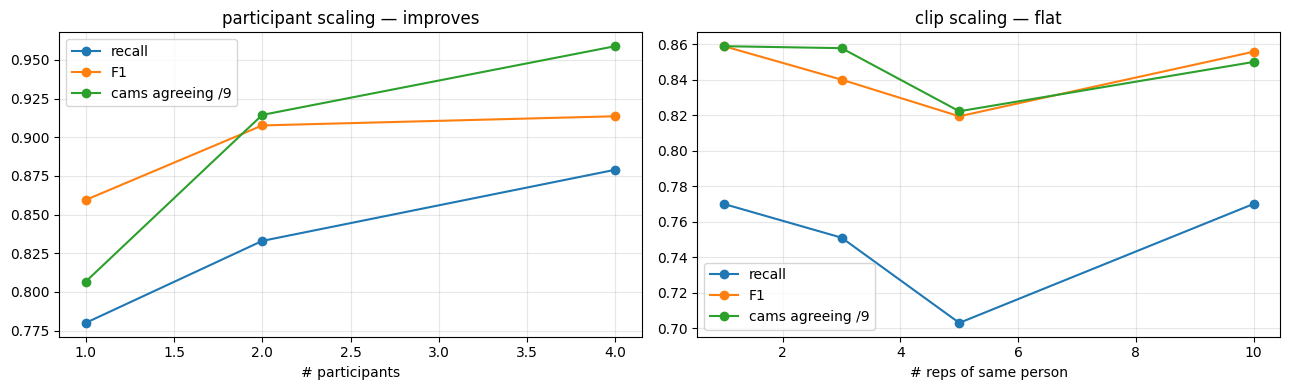

In [8]:
idx = json.load(open(DS / "results.json"))
def row(cfg):
    c = idx[cfg]; a = c.get("agreement", {})
    ev = json.load(open(RUNS / cfg / "eval_by_epoch.json"))
    last = ev[max(ev, key=lambda x: int(x))]
    return dict(cfg=cfg, recall=last.get("recall"), f1=last.get("f1"),
                tri=a.get("tri_rate"), cams=a.get("mean_cams_agreeing"), px=a.get("median_reproj_px"))
pscale = [row(c) for c in ["pscale_1","pscale_2","pscale_4"]]
cscale = [row(c) for c in ["cscale_1","cscale_3","cscale_5","cscale_10"]]

print("PARTICIPANT scaling (more people):")
for r in pscale: print(f"  {r['cfg']:<9} recall={r['recall']:.3f} F1={r['f1']:.3f} cams={r['cams']} px={r['px']}")
print("CLIP scaling (more reps of P01):")
for r in cscale: print(f"  {r['cfg']:<9} recall={r['recall']:.3f} F1={r['f1']:.3f} cams={r['cams']} px={r['px']}")

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot([1,2,4], [r['recall'] for r in pscale], "-o", label="recall")
ax[0].plot([1,2,4], [r['f1'] for r in pscale], "-o", label="F1")
ax[0].plot([1,2,4], [r['cams']/9 for r in pscale], "-o", label="cams agreeing /9")
ax[0].set_xlabel("# participants"); ax[0].set_title("participant scaling — improves"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot([1,3,5,10], [r['recall'] for r in cscale], "-o", label="recall")
ax[1].plot([1,3,5,10], [r['f1'] for r in cscale], "-o", label="F1")
ax[1].plot([1,3,5,10], [r['cams']/9 for r in cscale], "-o", label="cams agreeing /9")
ax[1].set_xlabel("# reps of same person"); ax[1].set_title("clip scaling — flat"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


**Headline (raw): participant diversity > clip count at a fixed budget.**
More *people* lifts held-out recall **0.78 → 0.88**, F1 → 0.91, coverage 7.3 → 8.6 cams.
More *reps of one person* is flat-to-negative (recall stuck ~0.70–0.77). The single-participant points agree across
both arms (pscale_1 ≈ cscale_1), an internal consistency check.

> ⚠️ **This headline is confounded — see §5b.** pscale_1 = P01, which carries the cam_10 static-glass garbage labels;
> adding participants partly just *dilutes* that poison. The controlled retrains below show the true participant effect
> is smaller than this raw curve suggests. Read §5b before trusting the magnitude.

**Confound check — is the gain just diluting P01's cam_10 glass?** Per-camera held-out recall says: partly.

In [9]:
pc = json.load(open(DS / "cache" / "percam" / "percam_recall.json"))
cams = sorted(pc["pscale_1"], key=lambda k: int(k.replace("cam","")))
print("cfg         " + " ".join(f"{c:>6}" for c in cams))
for cfg in ["pscale_1","pscale_4"]:
    print(f"{cfg:<12}" + " ".join(f"{pc[cfg].get(c,0):>6.2f}" for c in cams))
gain = {c: pc["pscale_4"].get(c,0) - pc["pscale_1"].get(c,0) for c in cams}
print("\ngain        " + " ".join(f"{gain[c]:>+6.2f}" for c in cams))
allg = np.mean(list(gain.values()))
no10 = np.mean([gain[c] for c in cams if c != "cam10"])
print(f"\nmean recall gain: all cams {allg:+.3f}  |  excluding cam10 {no10:+.3f}")
print(f"cam10 alone: {gain['cam10']:+.2f}  (pscale_1 NEVER detects held-out cam10 cup -> 0.00)")


cfg           cam1   cam2   cam3   cam4   cam5   cam6   cam7   cam8   cam9  cam10
pscale_1      0.94   0.94   0.68   0.78   0.57   0.90   0.75   0.78   0.66   0.00
pscale_4      0.97   0.99   0.85   0.92   0.78   0.83   0.82   0.97   0.90   0.67

gain         +0.03  +0.06  +0.18  +0.13  +0.21  -0.07  +0.07  +0.19  +0.24  +0.67

mean recall gain: all cams +0.170  |  excluding cam10 +0.114
cam10 alone: +0.67  (pscale_1 NEVER detects held-out cam10 cup -> 0.00)


**Decomposition:** the +0.17 headline recall gain is **~2/3 real generalization, ~1/3 cam_10 glass artifact**:
- **cam10: 0.00 → 0.67** — pscale_1 *never* detects the held-out cup in cam10 (it learned P01's static glass);
  adding participants dilutes that bad label. This single camera is ~4× the average gain.
- **But 8/10 cameras improve** (cam3 +0.18, cam5 +0.21, cam8 +0.19, cam9 +0.24 — glass-unrelated).
- **Mean gain: +0.17 all cameras → +0.11 excluding cam10.** So the participant effect is **real but inflated** by the glass.

### 5b. Is the confound real? Two controlled P01 retrains (same 3000-frame budget)

To separate "more people generalizes" from "the glass is poisoning training", we trained two more P01 students
(identical budget, only the *labels* differ): **drop_cam10** (train on cams 1–9, glass camera removed) and
**clean3d** (3D-inlier-gate every camera's labels — reject the glass/bracelet outliers, §4).

variant (all train on exactly 3000 frames):
  pscale_1   (raw, glass labels)      mean recall 0.700   cam10 0.00
  drop_cam10 (train cams 1-9)         mean recall 0.789   cam10 0.13
  clean3d    (3D-gate all cams)        mean recall 0.738   cam10 0.51


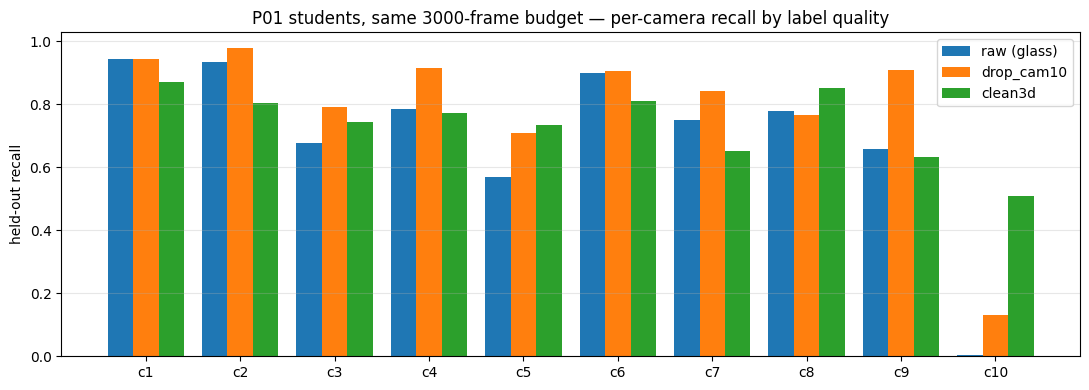

In [10]:
raw  = json.load(open(DS/"cache"/"percam"/"percam_recall.json"))["pscale_1"]
no10 = json.load(open(DS/"cache"/"percam"/"pscale_1_no10_recall.json"))
cl3d = json.load(open(DS/"cache"/"percam"/"pscale_1_clean3d_recall.json"))
cams = sorted(raw, key=lambda k: int(k.replace("cam","")))
def mean(d): return np.mean([d.get(c,0) for c in cams])
print("variant (all train on exactly 3000 frames):")
print(f"  pscale_1   (raw, glass labels)      mean recall {mean(raw):.3f}   cam10 {raw.get('cam10',0):.2f}")
print(f"  drop_cam10 (train cams 1-9)         mean recall {mean(no10):.3f}   cam10 {no10.get('cam10',0):.2f}")
print(f"  clean3d    (3D-gate all cams)        mean recall {mean(cl3d):.3f}   cam10 {cl3d.get('cam10',0):.2f}")

x = np.arange(len(cams)); w = 0.27
plt.figure(figsize=(11,4))
plt.bar(x-w, [raw.get(c,0) for c in cams], w, label="raw (glass)")
plt.bar(x,   [no10.get(c,0) for c in cams], w, label="drop_cam10")
plt.bar(x+w, [cl3d.get(c,0) for c in cams], w, label="clean3d")
plt.xticks(x, [c.replace("cam","c") for c in cams]); plt.ylabel("held-out recall")
plt.title("P01 students, same 3000-frame budget — per-camera recall by label quality")
plt.legend(); plt.grid(alpha=.3, axis="y"); plt.tight_layout(); plt.show()


**Findings — the confound is real, and the fix is subtle:**

| variant (3000 frames) | mean recall | cam10 | cam4 |
|---|---|---|---|
| pscale_1 (raw, glass) | 0.700 | 0.00 | 0.78 |
| **drop_cam10** (cams 1–9) | **0.789** | 0.13 | 0.92 |
| clean3d (3D-gate all) | 0.738 | **0.51** | 0.77 |

- **The glass was a *global* poison, not a localized one.** Just removing cam_10 from P01's training lifts mean held-out
  recall **0.70 → 0.79** — and the gain is spread across glass-*unrelated* cameras (cam9 +0.25, cam5 +0.14, cam4 +0.13).
  So training on "cup = static corner glass" degraded the student's cup representation *everywhere*.
- **3D-cleaning uniquely recovers the hard cam_10 view: 0.00 → 0.51** — drop_cam10 can't (no cam_10 data to learn from,
  stays 0.13). Per-detection cleaning beats dropping a whole camera *for that camera*.
- **But reject-only 3D-cleaning over-prunes** (it dropped **40%** of labels — glass + bracelet + every <3-cam-consensus
  frame), losing good hard frames → other cameras regress, so its *mean* (0.738) loses to surgical drop_cam10 (0.789).

**Revised conclusion for §5:** the raw "participants ≫ clips" headline was **substantially confounded by P01's glass**.
The true participant effect is smaller than the sweep suggested; a single contaminated camera dragged recall down across
all views. The right fix is geometric per-detection cleaning (it recovers cam_10 without dropping a camera) — but with a
**looser gate or reproject-fill**, since reject-only at ≥3-cam consensus discards too much. The clean scaling curves
should be re-run on 3D-cleaned labels.

## 6. E6 — camera-transfer matrix (viewpoint vs volume)

Train 10 single-camera students on P01 (reps 1–10, ~3000 frames), test each per-camera on held-out P01 reps 11–15
(same person, isolating pure camera-to-camera transfer).

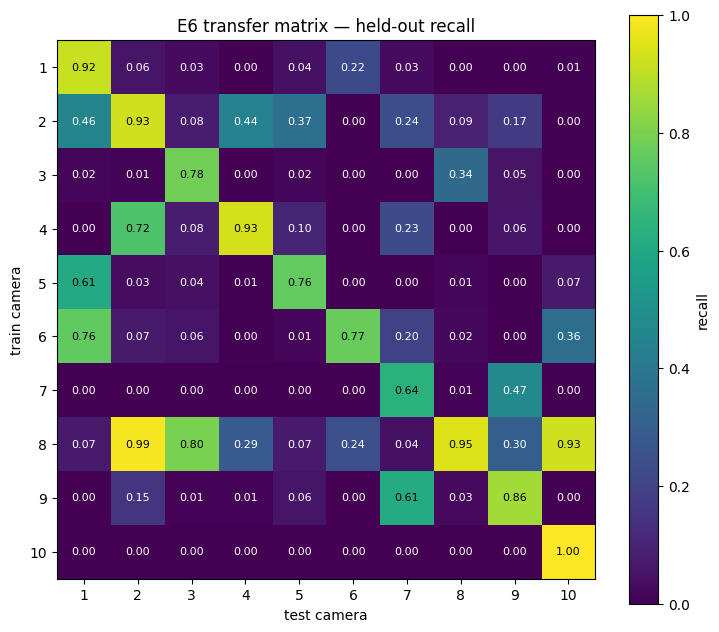

train frames per camera: {1: 3000, 2: 3000, 3: 3000, 4: 3000, 5: 2754, 6: 1780, 7: 2594, 8: 707, 9: 1188, 10: 3000}
cam8 (707 frames) transfers to: 6 /10 cameras


In [11]:
M = json.load(open(DS / "e6" / "transfer_matrix.json"))
cams = list(range(1,11))
mat = np.array([[ (M[f"cam{tr}"].get(f"cam{te}") or 0.0) for te in cams] for tr in cams])
fig, ax = plt.subplots(figsize=(7.5,6.5))
im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(cams); ax.set_yticks(range(10)); ax.set_yticklabels(cams)
ax.set_xlabel("test camera"); ax.set_ylabel("train camera"); ax.set_title("E6 transfer matrix — held-out recall")
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center",
                color="white" if mat[i,j] < .6 else "black", fontsize=8)
fig.colorbar(im, label="recall"); plt.tight_layout(); plt.show()

frames = {1:3000,2:3000,3:3000,4:3000,5:2754,6:1780,7:2594,8:707,9:1188,10:3000}
print("train frames per camera:", frames)
print("cam8 (707 frames) transfers to:", sum(1 for te in cams if (M['cam8'].get(f'cam{te}') or 0)>0.25), "/10 cameras")


**Findings:**
1. **Diagonal always strong** (own-view recall 0.64–1.0) **even cam8 on 707 frames** → 3000 is past saturation;
   **data volume is not the bottleneck.**
2. **Transfer is a property of the source viewpoint, not volume.** Hubs: **cam8 (707 frames!) → 7/10 cameras**, cam2 → ~5.
   Loners (own view only): cam1, cam3, cam7, cam10.
3. **Viewpoint-adjacency structure:** reciprocal pairs cam2↔cam4, cam7↔cam9; cam10 reachable only via cam6 / cam8.
4. **cam10 row = 1.0 own / 0.0 all others = static-glass memorization** — the student learned a fixed false positive;
   trivially perfect on its own view, useless elsewhere. End-to-end confirmation of the cam_10 distractor.

→ **Pick training cameras for viewpoint coverage (a hub + one per isolated pair), not for frame count.**

## 7. Takeaways & open threads

**What we learned**
- **Early stop:** held-out F1 / val_cls (presence losses) saturate ~ep8–10; box-loss keeps dropping (overfit). Use a
  presence-based plateau, not total val-loss.
- **The agreement metric** needs inlier-gated triangulation — one rogue camera (cam_4) otherwise dominates the number.
  It is a no-GT **precision** signal that catches what presence-recall can't: ep5 looked top-tier on recall yet the
  cameras disagreed 4× (§3a) — a wrong-but-confident epoch you'd otherwise early-stop on.
- **KF accuracy budget (§3b):** the 3D tracker absorbs detection jitter up to **~±20px (1σ)** then fails *catastrophically*
  (>1m, grabs the glass), and needs **≥3 well-spread cameras** (2 is degenerate). So aim for *some* detection in ≥3
  spread views within ±20px — not pixel-perfect localization in any one. This is exactly the 30px/≥3-cam rule the §4
  cleaner uses.
- **Label cleaning** is a 4-stage filter (2D-KF → 3D gate → 3D-KF → RTS). The last three were missing; all validated on
  P01. 3D gating kills the static-glass FP (100%); 3D-KF/RTS fill occlusion gaps (coverage 67→100%).
- **Data collection:** participant breadth ≫ clips-per-person; viewpoint coverage ≫ frames-per-camera. Both say the same
  thing — at a fixed budget, **diversity beats volume**.

**Open threads**
- Integrate the 3D-gate→RTS cleaner into `pseudo_label` for calibrated participants; re-label P01, retrain, confirm the
  student finally detects cam_10's cup on held-out data.
- Calibrate the rest of the training pool (P02–P05, P08–P10) so 3D label cleaning applies to all training data.
- Wire the presence-based early-stop into the harness.